# 01 — EDA

Sanity-check the data layer and produce the report's data-section figures.

In [4]:
# === Bootstrap (Colab + local) ===
import sys, os
try:
    import google.colab  # noqa: F401
    get_ipython().system('test -d /content/fys5419 || git clone -q https://github.com/egil10/fys5419.git /content/fys5419')
    get_ipython().run_line_magic('cd', '/content/fys5419/project2/code/notebooks')
except ImportError:
    pass
sys.path.append('..')
from scripts.colab import setup; setup()

# === Project imports ===
from scripts.data     import load_returns
from scripts.baskets  import BASKETS, config
from scripts.snp      import SNP
from scripts.plotting import apply_style
apply_style()

/content/fys5419/project2/code/notebooks
> git -C /content/fys5419 pull
> /usr/bin/python3 -m pip install -q numpy pandas scipy matplotlib yfinance pyarrow
[colab.setup] env=Colab
[colab.setup] cwd  = /content/fys5419/project2/code/notebooks
[colab.setup] path = /content/fys5419/project2/code  (added to sys.path)


In [5]:
BASKET = 'mag7'
tickers, start, end = config(BASKET)
r = load_returns(tickers, start, end, cache_name=BASKET)
print(f'{BASKET}: {r.tickers}  n={r.n}  obs={len(r.prices)}')

⟳ cache stale (cache starts 2023-01-03 after requested 2023-01-01); re-fetching
✓ 751 1d obs for ['AAPL', 'MSFT', 'GOOGL', 'AMZN'] (2023-01-03 → 2025-12-30)
✓ cached → data/mag7.parquet
✓ sample → data/mag7_sample.csv
mag7: ('AAPL', 'MSFT', 'GOOGL', 'AMZN')  n=4  obs=751


### Per-basket overview (6-panel EDA from `snp.py`)

⟳ cache stale (cache starts 2023-01-03 after requested 2023-01-01); re-fetching
✓ 751 1d obs for ['AAPL', 'MSFT', 'GOOGL', 'AMZN'] (2023-01-03 → 2025-12-30)
✓ cached → data/mag7.parquet
✓ sample → data/mag7_sample.csv

4 assets, 751 1d obs
Ticker     Ann.Ret   Ann.Vol    Sharpe
AAPL        26.74%    25.46%     1.050
MSFT        24.66%    23.13%     1.066
GOOGL       42.55%    30.24%     1.407
AMZN        33.49%    31.86%     1.051
✓ saved → plots/eda/mag7_overview.pdf


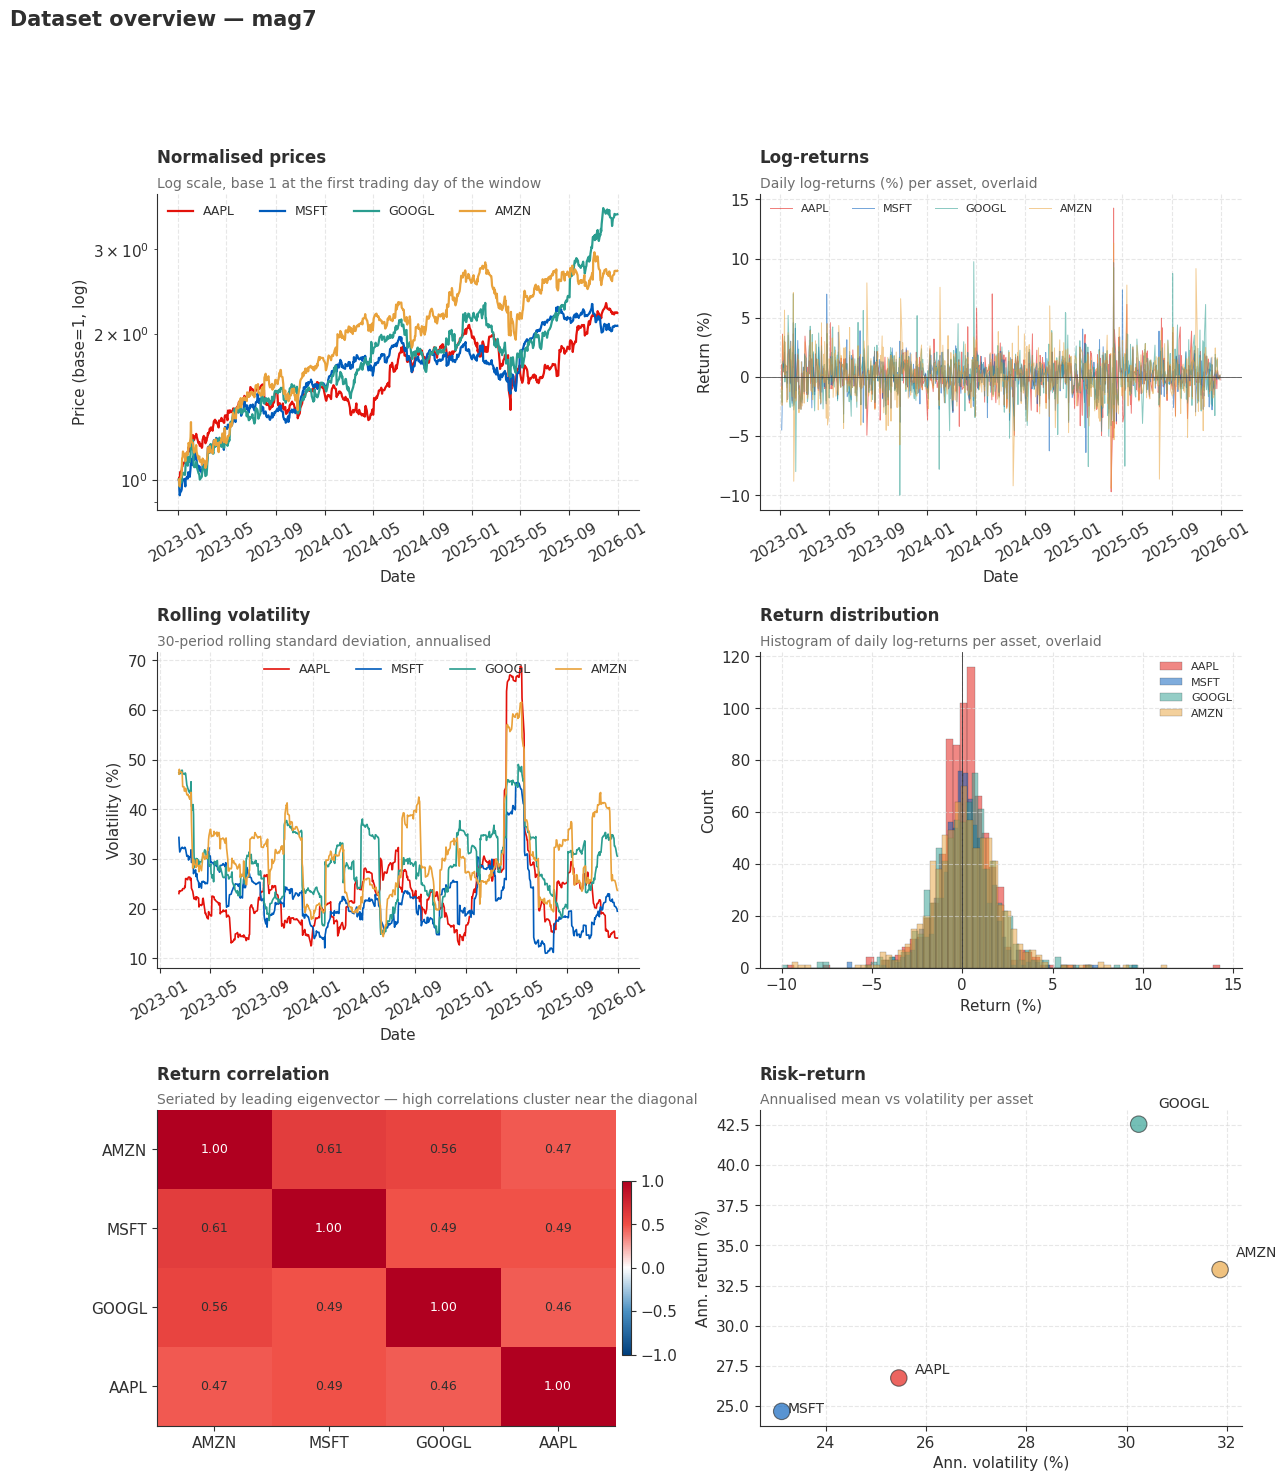

⟳ cache stale (cache starts 2023-01-03 after requested 2023-01-01); re-fetching
✓ 751 1d obs for ['IONQ', 'RGTI', 'QBTS', 'QUBT'] (2023-01-03 → 2025-12-30)
✓ cached → data/quantum.parquet
✓ sample → data/quantum_sample.csv

4 assets, 751 1d obs
Ticker     Ann.Ret   Ann.Vol    Sharpe
IONQ        86.43%   100.05%     0.864
RGTI       115.15%   143.41%     0.803
QBTS        97.54%   146.41%     0.666
QUBT        64.62%   139.01%     0.465
✓ saved → plots/eda/quantum_overview.pdf


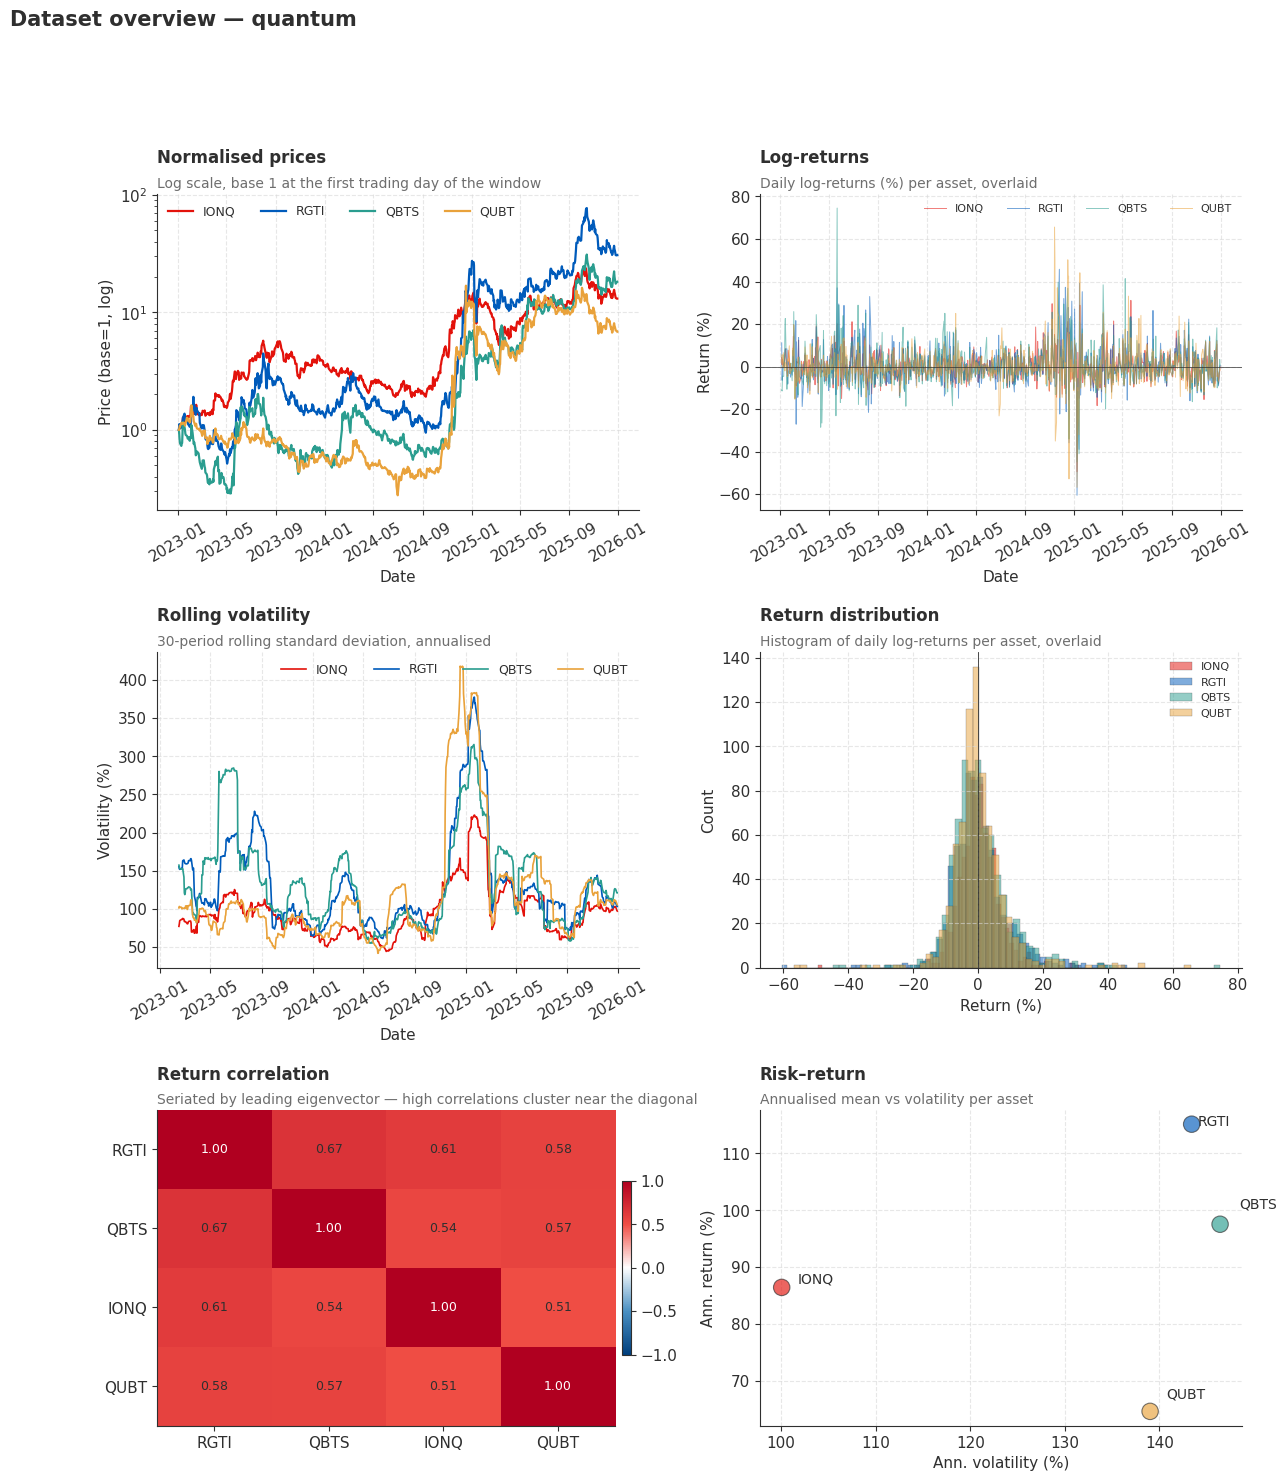

⟳ cache stale (cache starts 2023-01-03 after requested 2023-01-01); re-fetching
✓ 751 1d obs for ['IBM', 'HON', 'ACN', 'NVDA'] (2023-01-03 → 2025-12-30)
✓ cached → data/quantum_big.parquet
✓ sample → data/quantum_big_sample.csv

4 assets, 751 1d obs
Ticker     Ann.Ret   Ann.Vol    Sharpe
IBM         29.15%    23.70%     1.230
HON          1.22%    20.59%     0.059
ACN          1.51%    25.14%     0.060
NVDA        86.48%    49.64%     1.742
✓ saved → plots/eda/quantum_big_overview.pdf


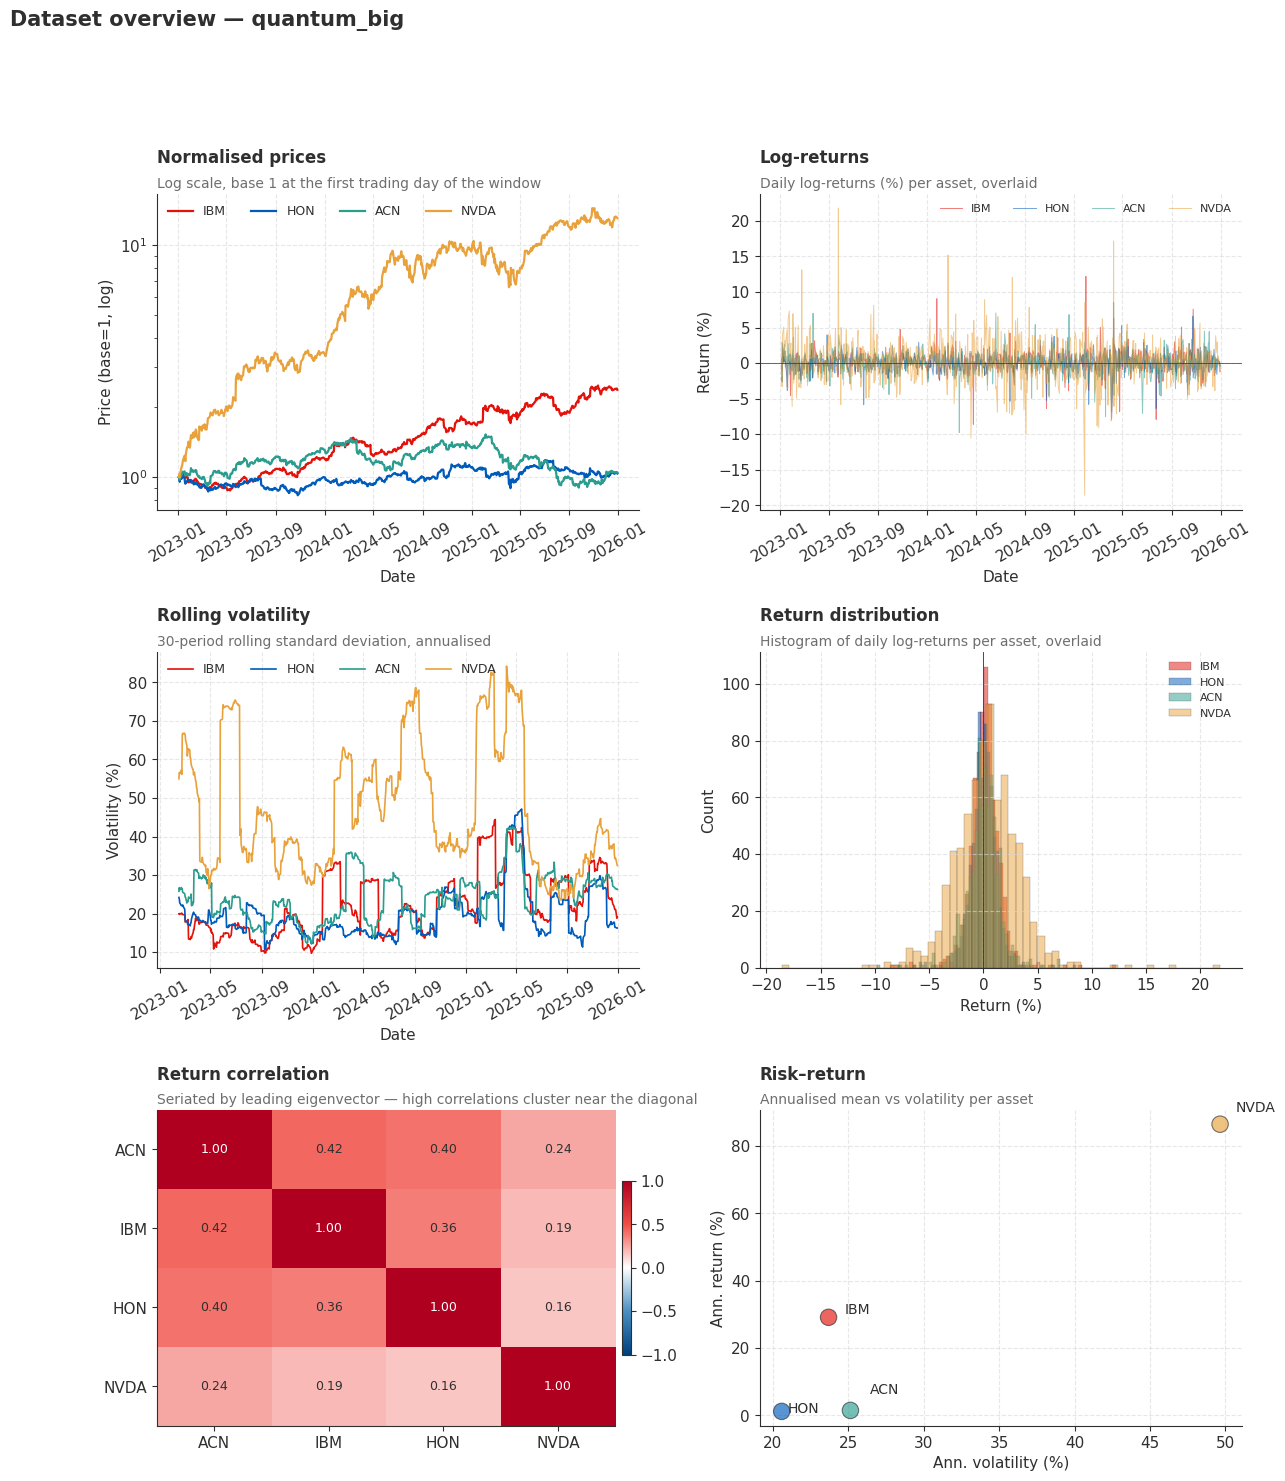

⟳ cache stale (cache starts 2023-01-03 after requested 2023-01-01); re-fetching
✓ 751 1d obs for ['XOM', 'DAL', 'NEM', 'JPM'] (2023-01-03 → 2025-12-30)
✓ cached → data/anti.parquet
✓ sample → data/anti_sample.csv

4 assets, 751 1d obs
Ticker     Ann.Ret   Ann.Vol    Sharpe
XOM          7.75%    22.66%     0.342
DAL         26.27%    38.45%     0.683
NEM         26.92%    37.06%     0.726
JPM         31.81%    23.07%     1.379
✓ saved → plots/eda/anti_overview.pdf


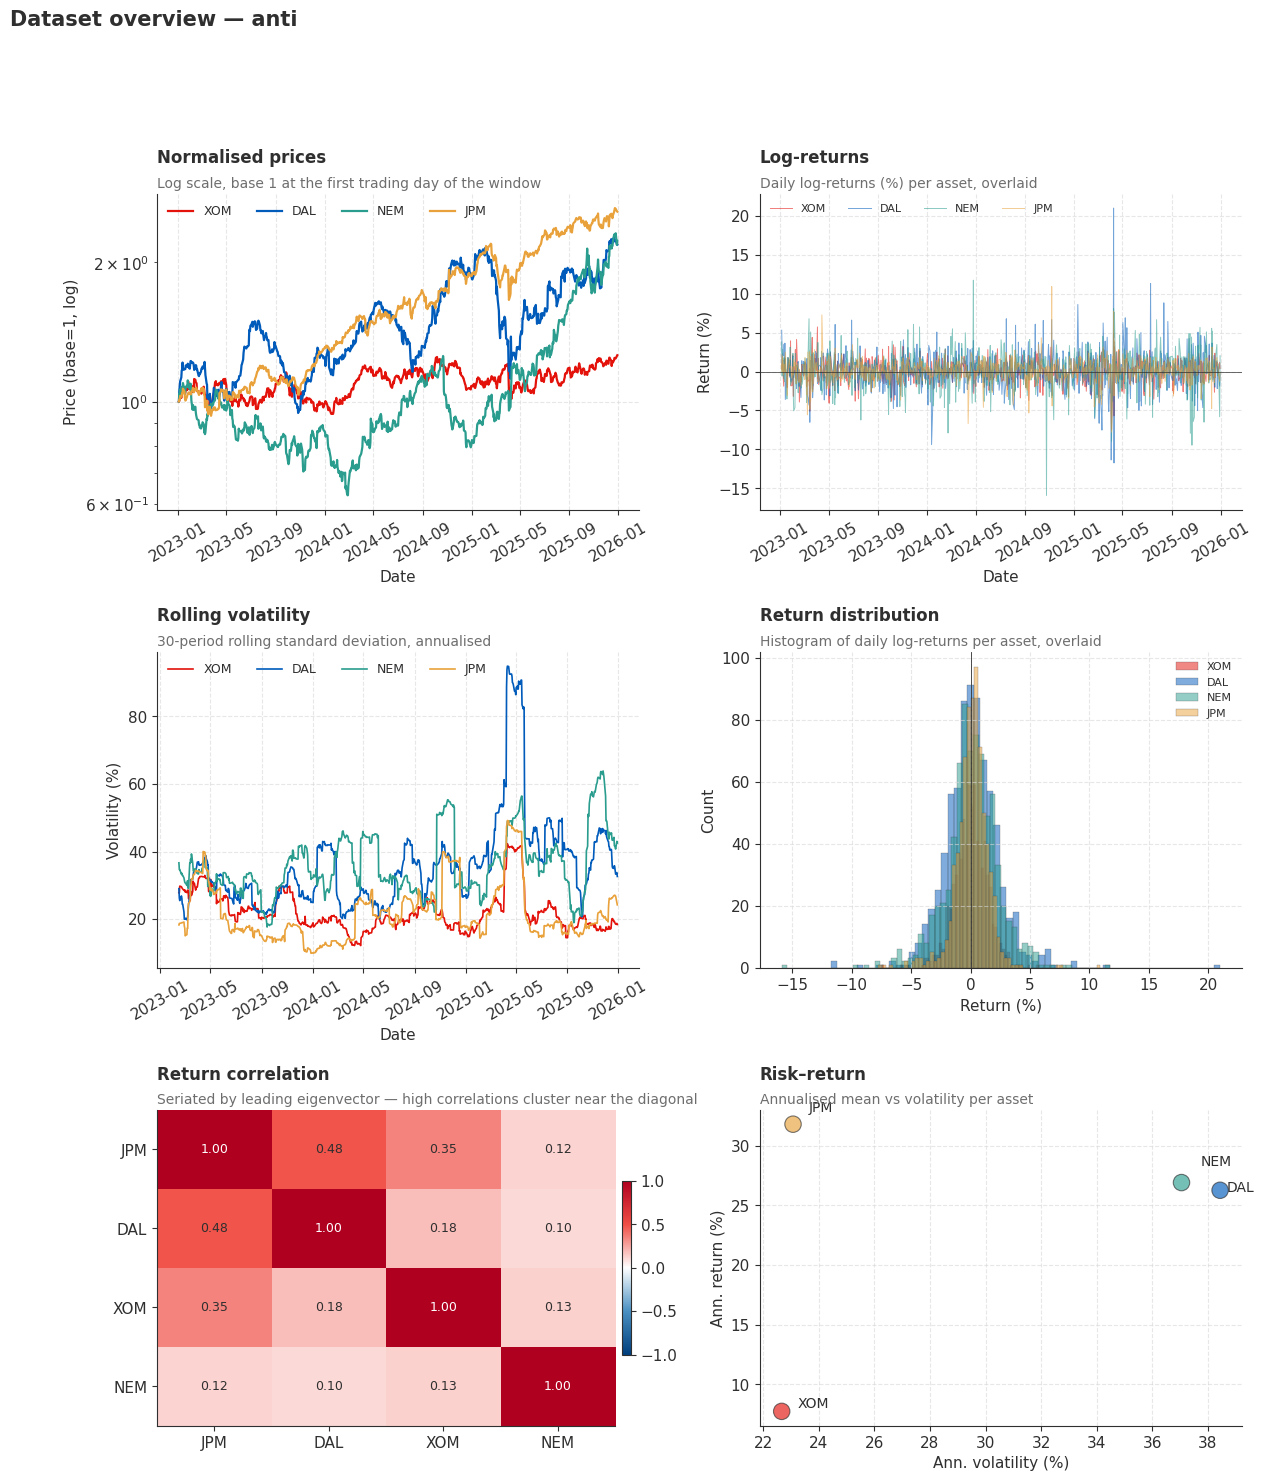

In [6]:
for name in BASKETS:
    snp = SNP(list(config(name)[0]), start, end).cached_fetch(name=name)
    snp.summary()
    snp.plot(save=True, name=name)